In [17]:
import os
import pandas as pd
from netCDF4 import Dataset
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from scipy.interpolate import griddata
import matplotlib.ticker as mticker

In [18]:
# To use PLUMBER2_GPP_common_utils, change directory to where it exists
os.chdir('/g/data/w97/mm3972/scripts/PLUMBER2/LSM_GPP_PLUMBER2')
from PLUMBER2_GPP_common_utils import *

### Calculate daily GPP

In [10]:
def calculate_daily_GPP(site_name):
    
    secondly_to_hourly = 3600.

    # prepare dataset
    PLUMBER2_path_site = f"/g/data/w97/mm3972/scripts/PLUMBER2/LSM_GPP_PLUMBER2/nc_files/{site_name}.nc"
    f                  = nc.Dataset(PLUMBER2_path_site, mode='r')
    var                = pd.DataFrame(f.variables['obs_GPP'][:].data, columns=['GPP'])

    # Read time
    time               = nc.num2date(f.variables['CABLE_time'][:],f.variables['CABLE_time'].units,
                         only_use_cftime_datetimes=False,only_use_python_datetimes=True)
    ntime              = len(time)
    
    time_intervals = np.diff(time)[0]/timedelta(seconds=3600)
    day_tot_step   = int(24/time_intervals)

    year           = np.zeros(ntime)
    month          = np.zeros(ntime)
    day            = np.zeros(ntime)
    
    for tt,t in enumerate(time):
        year[tt]  = t.year
        month[tt] = t.month
        day[tt]   = t.day

    var['year']   = year
    var['month']  = month
    var['day']    = day
        
    # Change units from gC/m2/s to gC/m2/time step
    var.loc[:,'GPP'] = var['GPP'][:]*secondly_to_hourly*time_intervals
    var_daily        = var.groupby(['year', 'month', 'day']).sum(numeric_only=True).reset_index()

    if site_name == 'SD-Dem':
        var_daily = var_daily[var_daily.index != 2006]
    elif site_name == 'US-PFa':
        var_daily = var_daily[var_daily.index != 1995]
    
    unique_year = np.unique(year)
    for uyr in unique_year:
        if np.sum(year == uyr) < 200:
            var_daily = var_daily[var_daily.year != uyr]
            print(site_name, uyr, 'only has ', np.sum(year == uyr), 'data, removed')

    # Calculate 95th 
    percentile_95_GPP = var_daily.groupby('year')['GPP'].quantile(0.95).reset_index()
    
    print(var_daily)
    print(percentile_95_GPP)
    
    return
    

In [52]:
def calculate_daily_GPP(site_name):
    
    secondly_to_hourly = 3600.

    # Prepare dataset
    PLUMBER2_path_site = f"/g/data/w97/mm3972/scripts/PLUMBER2/LSM_GPP_PLUMBER2/nc_files/{site_name}.nc"
    f                  = nc.Dataset(PLUMBER2_path_site, mode='r')
    var                = pd.DataFrame(f.variables['obs_GPP'][:].data, columns=['GPP'])

    # Read time
    time               = nc.num2date(f.variables['CABLE_time'][:], f.variables['CABLE_time'].units,
                         only_use_cftime_datetimes=False, only_use_python_datetimes=True)
    ntime              = len(time)
    
    time_intervals = np.diff(time)[0] / timedelta(seconds=3600)
    day_tot_step   = int(24 / time_intervals)

    year           = np.zeros(ntime)
    month          = np.zeros(ntime)
    day            = np.zeros(ntime)
    
    for tt, t in enumerate(time):
        year[tt]  = t.year
        month[tt] = t.month
        day[tt]   = t.day

    var['year']   = year
    var['month']  = month
    var['day']    = day
        
    # Change units from gC/m2/s to gC/m2/time step
    var.loc[:, 'GPP'] = var['GPP'][:] * secondly_to_hourly * time_intervals
    var_daily         = var.groupby(['year', 'month', 'day']).sum(numeric_only=True).reset_index()

    # Calculate the 15-day rolling mean of GPP
    var_daily['GPP_15d_smooth'] = var_daily['GPP'].rolling(window=15, min_periods=1, center=True).mean()

    if site_name == 'SD-Dem':
        var_daily = var_daily[var_daily.index != 2006]
    elif site_name == 'US-PFa':
        var_daily = var_daily[var_daily.index != 1995]
    
    unique_year = np.unique(year)
    
    for uyr in unique_year:
        if np.sum(year == uyr) < 200:
            var_daily = var_daily[var_daily.year != uyr]
            print(site_name, uyr, 'only has ', np.sum(year == uyr), 'data, removed')

    # Calculate 95th percentile for each year
    percentile_95_GPP = var_daily.groupby('year')['GPP'].quantile(0.95).reset_index()
    percentile_95_GPP.rename(columns={'GPP': '95th_percentile_GPP'}, inplace=True)
    
    # Merge the 95th percentile values back into the var_daily DataFrame
    var_daily = pd.merge(var_daily, percentile_95_GPP, on='year')

    # Set GPP to np.nan if GPP is less than half of the 95th percentile of that year
    var_daily['GPP_growing_season_only'] = np.where( var_daily['GPP_15d_smooth'] < var_daily['95th_percentile_GPP'] / 2, 
                                                      np.nan, var_daily['GPP'] )
    
    var_daily['is_growing_season']       = np.where(np.isnan(var_daily['GPP_growing_season_only']), 0, 1)
    
    plt.plot(var_daily['GPP'], c='black')
    plt.plot(var_daily['GPP_growing_season_only'], c='green')      
    plt.show()
    
    return var_daily

# Example usage
# daily_GPP = calculate_daily_GPP('SD-Dem')


US-Ha1 2013.0 only has  1 data, removed


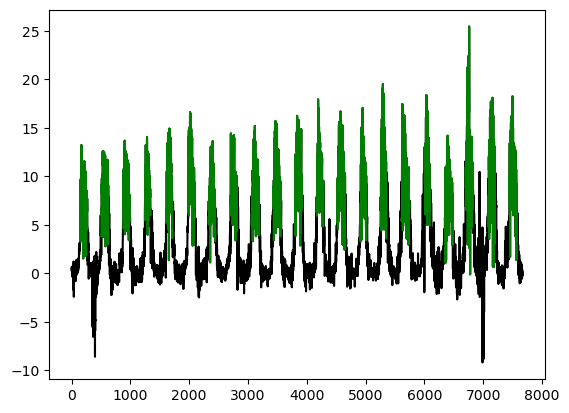

,year,month,day,GPP,GPP_15d_smooth,95th_percentile_GPP,GPP_growing_season_only,is_growing_season
0,1992.0,1.0,1.0,0.496167,0.341150,9.923872,NaN,0
1,1992.0,1.0,2.0,0.277456,0.319156,9.923872,NaN,0
2,1992.0,1.0,3.0,0.397721,0.304213,9.923872,NaN,0
3,1992.0,1.0,4.0,0.213071,0.298212,9.923872,NaN,0
4,1992.0,1.0,5.0,0.684581,0.296056,9.923872,NaN,0
...,...,...,...,...,...,...,...,...
7666,2012.0,12.0,27.0,0.148725,0.118245,14.267031,NaN,0
7667,2012.0,12.0,28.0,-0.269748,0.050537,14.267031,NaN,0
7668,2012.0,12.0,29.0,-0.120700,0.021165,14.267031,NaN,0
7669,2012.0,12.0,30.0,-0.090866,0.077614,14.267031,NaN,0


In [55]:
calculate_daily_GPP('US-Ha1')